# Mental Health Intent Classification
Fine-tuning `tod-bert` for student query routing.

**Run cells top to bottom. After training, the model is saved to `../model/`.**

## 1. Install Dependencies

In [1]:
# Run this once, then restart kernel if needed
# !pip install transformers torch datasets scikit-learn pandas matplotlib seaborn

In [2]:
import subprocess, sys

packages = [
    "transformers",
    "torch",
    "datasets",
    "scikit-learn",
    "pandas",
    "matplotlib",
    "seaborn",
    "streamlit",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])

0

In [3]:
import os
print(os.getcwd())

/content


## 2. Imports

In [17]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
from collections import Counter # <-- ADD THIS IMPORT

import torch
from torch.utils.data import Dataset, DataLoader
# from transformers import (
#     BertTokenizer,
#     BertForSequenceClassification,
#     get_linear_schedule_with_warmup
# )
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 3. Load & Explore Data

In [6]:
# For Local Device:
# JSON_PATH = Path.cwd().parent / "dataset" / "intents.json"
# For Google Colab:
JSON_PATH = "dataset/intents.json"

# 1. Load and parse the JSON structured file
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

# 2. Parse patterns and tags into flat list rows
formatted_data = []
for intent in data['intents']:
    tag = intent['tag']
    for pattern in intent['patterns']:
        formatted_data.append({
            'text': pattern,
            'intent': tag
        })

# 3. Create a unified DataFrame
df = pd.DataFrame(formatted_data)

In [7]:
# ── Adjust these two lines to match your actual column names ──────────────
TEXT_COL  = 'text'
LABEL_COL = 'intent'
# ─────────────────────────────────────────────────────────────────────────

# 4. Encode string labels → integers
le = LabelEncoder()
df['label_id'] = le.fit_transform(df[LABEL_COL])

NUM_LABELS = len(le.classes_)
print(f'\nNumber of classes: {NUM_LABELS}')

print('\nClass mapping:')
for i, c in enumerate(le.classes_):
    print(f'  {i} → {c}')

# 5. Split cleanly into Train & Test (80% Train, 20% Test)
# Stratify keeps class representation uniform across both splits
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label_id']
)
# potential bug fix
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('\nTrain shape:', train_df.shape)
print('Test shape: ', test_df.shape)

# Debug view to ensure it matches your pipeline's expectations
print("\nFirst 5 rows of Train Data:")
print(train_df[[TEXT_COL, LABEL_COL, 'label_id']].head())


Number of classes: 9

Class mapping:
  0 → anger
  1 → depression
  2 → gratitude
  3 → greeting
  4 → loneliness
  5 → motivation
  6 → relationship
  7 → self_care
  8 → stress

Train shape: (1640, 3)
Test shape:  (410, 3)

First 5 rows of Train Data:
                                                 text      intent  label_id
1850                           I appreciate your time   gratitude         2
1961            I appreciate your kindness and warmth   gratitude         2
1988  I appreciate the comfort you bring into my life   gratitude         2
1297        I feel like I'm just existing, not living  loneliness         4
1304         I feel like I'm not a priority to anyone  loneliness         4


In [8]:
print(train_df.columns)

Index(['text', 'intent', 'label_id'], dtype='object')


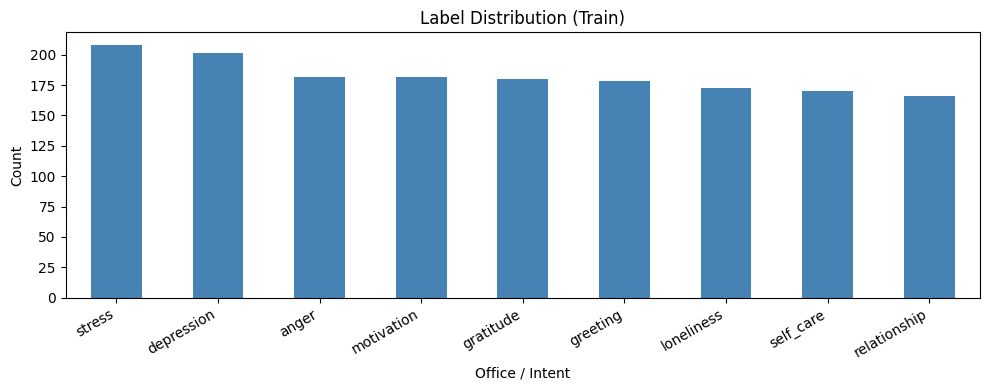

In [9]:
# Label distribution plot
plt.figure(figsize=(10, 4))
train_df[LABEL_COL].value_counts().plot(kind='bar', color='steelblue')
plt.title('Label Distribution (Train)')
plt.xlabel('Office / Intent')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [11]:
# Drop rows with missing text
train_df = train_df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
test_df  = test_df.dropna(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
print('After dropping NaN — Train:', len(train_df), '| Test:', len(test_df))

After dropping NaN — Train: 1640 | Test: 410


## 5. Dataset & DataLoader

In [12]:
# MODEL_NAME = 'bert-base-uncased'
MODEL_NAME = 'TODBERT/TOD-BERT-JNT-V1'
# MAX_LEN    = 128
MAX_LEN    = 256
BATCH_SIZE = 16

# tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.tolist()
        self.labels    = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = IntentDataset(train_df[TEXT_COL], train_df['label_id'], tokenizer, MAX_LEN)
test_dataset  = IntentDataset(test_df[TEXT_COL],  test_df['label_id'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/32.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Train batches: 103 | Test batches: 26


## 6. Model Setup

In [13]:
# model = BertForSequenceClassification.from_pretrained(
#     MODEL_NAME,
#     num_labels=NUM_LABELS
# )
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model = model.to(DEVICE)

# EPOCHS    = 4
EPOCHS    = 6
# LR        = 2e-5
LR        = 1e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f'Total training steps: {total_steps}')

[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `2`.


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: TODBERT/TOD-BERT-JNT-V1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps: 618


## 7. Training

In [14]:
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in tqdm(loader, desc='Training'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Extract cleanly using detach() and cpu()
        preds = outputs.logits.argmax(dim=1)

        # Debug print for first batch
        if total == 0:
            print("\nFirst batch predictions:")
            print(preds[:20].detach().cpu().numpy())
            print("First batch labels:")
            print(labels[:20].detach().cpu().numpy())

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

# Run standard clean loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    vl_loss, vl_acc = eval_epoch(model, test_loader, DEVICE)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch}/{EPOCHS} '
          f'| train loss {tr_loss:.4f} acc {tr_acc:.4f} '
          f'| val loss {vl_loss:.4f} acc {vl_acc:.4f}')

Training:   0%|          | 0/103 [00:00<?, ?it/s]


First batch predictions:
[5 5 5 5 5 4 5 5 7 0 2 5 5 5 5 5]
First batch labels:
[8 3 6 3 1 4 1 0 3 0 6 7 2 2 4 3]


Evaluating:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 1/6 | train loss 2.1349 acc 0.2146 | val loss 1.7957 acc 0.5390


Training:   0%|          | 0/103 [00:00<?, ?it/s]

...

Epoch 5/6 | train loss 0.6472 acc 0.8689 | val loss 0.5591 acc 0.8707


Training:   0%|          | 0/103 [00:00<?, ?it/s]


First batch predictions:
[7 6 1 3 0 7 8 4 6 5 3 8 5 1 4 7]
First batch labels:
[7 6 1 3 1 7 8 4 6 5 3 0 5 1 4 5]


Evaluating:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 6/6 | train loss 0.5864 acc 0.8823 | val loss 0.5348 acc 0.8756


## 8. Training Curves

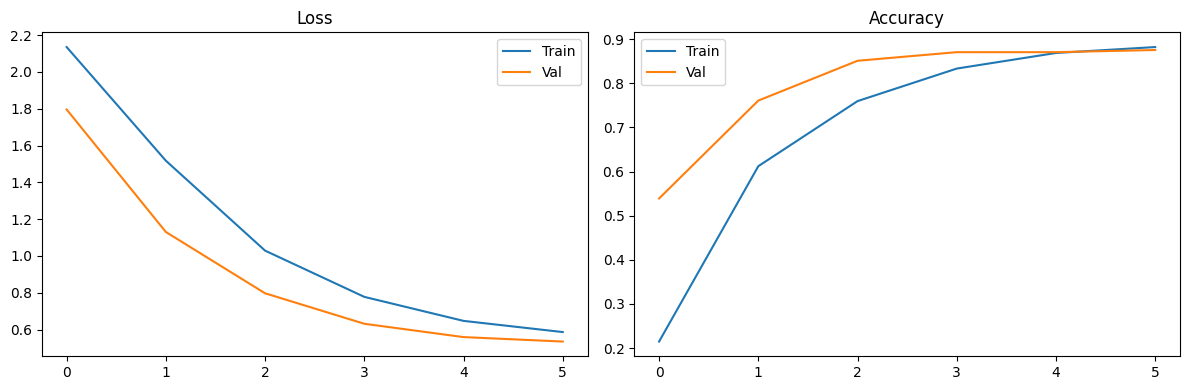

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluation

In [18]:
# Inference

# FIX: Explicitly clear and initialize metric lists
all_preds = []
all_labels = []

model.eval()
# all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # Extract cleanly: move predictions to CPU and map to a NumPy array
        preds = outputs.logits.argmax(dim=1).detach().cpu().numpy()
        labels = batch['label'].numpy()  # Already on CPU as it is from standard batch dictionary

        # Use extend() with safe 1D numpy iterables
        all_preds.extend(preds)
        all_labels.extend(labels)

# Print tracking distributions to inspect variations
print("Prediction Distribution:")
print(Counter(all_preds))

print("\nTrue Label Distribution:")
print(Counter(all_labels))

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=le.classes_
))

Prediction Distribution:
Counter({np.int64(0): 62, np.int64(4): 49, np.int64(2): 46, np.int64(5): 45, np.int64(3): 44, np.int64(7): 44, np.int64(6): 43, np.int64(8): 39, np.int64(1): 38})

True Label Distribution:
Counter({np.int64(8): 52, np.int64(1): 50, np.int64(0): 46, np.int64(5): 45, np.int64(2): 45, np.int64(3): 44, np.int64(4): 43, np.int64(7): 43, np.int64(6): 42})

Classification Report:
              precision    recall  f1-score   support

       anger       0.73      0.98      0.83        46
  depression       0.82      0.62      0.70        50
   gratitude       0.98      1.00      0.99        45
    greeting       1.00      1.00      1.00        44
  loneliness       0.76      0.86      0.80        43
  motivation       0.96      0.96      0.96        45
relationship       0.98      1.00      0.99        42
   self_care       0.93      0.95      0.94        43
      stress       0.79      0.60      0.68        52

    accuracy                           0.88       410
   

In [19]:
# from collections import Counter

# print(Counter(predictions))

all_preds.extend(preds)
all_labels.extend(batch['label'].numpy())

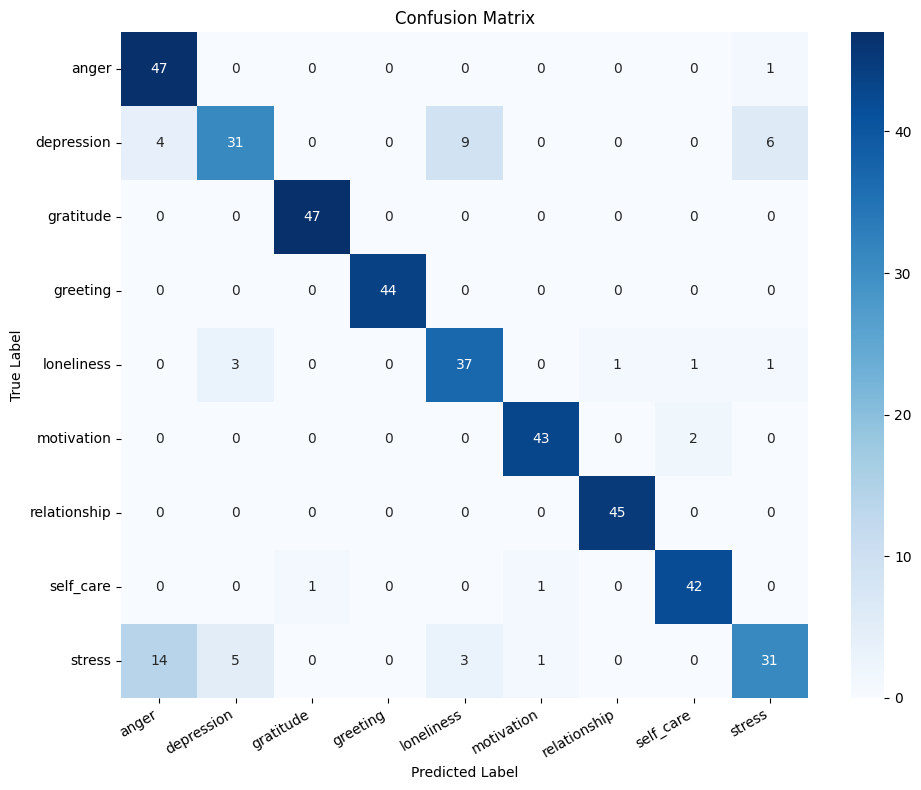

In [20]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 10. Save Model + Label Mapping

In [21]:
SAVE_DIR = '../model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save BERT weights + tokenizer
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save label mapping so app.py can decode predictions
label_map = {str(i): label for i, label in enumerate(le.classes_)}
with open(os.path.join(SAVE_DIR, 'label_map.json'), 'w') as f:
    json.dump(label_map, f, indent=2)

print('Saved to', SAVE_DIR)
print('Label map:', label_map)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ../model
Label map: {'0': 'anger', '1': 'depression', '2': 'gratitude', '3': 'greeting', '4': 'loneliness', '5': 'motivation', '6': 'relationship', '7': 'self_care', '8': 'stress'}


## 11. Quick Sanity Check
Test a few example queries before launching the app.

In [22]:
# def predict(text, model, tokenizer, label_map, device, max_len=128):
def predict(text, model, tokenizer, label_map, device, max_len=256):
    model.eval()
    enc = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device)
        )
    pred_id = outputs.logits.argmax(dim=1).item()
    probs   = torch.softmax(outputs.logits, dim=1)[0].cpu().numpy()
    return label_map[str(pred_id)], float(probs[pred_id])


sample_queries = [
    'I have not received my scholarship payment yet',
    'My student email account is not working',
    'I want to request a transcript',
    'When is the deadline to add or drop a course?',
    'The WiFi in the dorm keeps disconnecting',
]

for q in sample_queries:
    intent, conf = predict(q, model, tokenizer, label_map, DEVICE)
    print(f'  [{conf:.0%}] "{q}"')
    print(f'        → {intent}\n')

  [16%] "I have not received my scholarship payment yet"
        → depression

  [21%] "My student email account is not working"
        → self_care

  [47%] "I want to request a transcript"
        → motivation

  [23%] "When is the deadline to add or drop a course?"
        → motivation

  [47%] "The WiFi in the dorm keeps disconnecting"
        → stress

